### Limpieza de los ficheros de límte de ruido
## El fichero analizado es 03_DF3_4F_NoiseLimitDetails.csv. Se carga desde Kaggle y se limpia y normalizan los .
 # Este dataset:
# ✅ procede de normativa europea (END – Environmental Noise Directive)
# ✅ contiene umbrales normativos de ruido
# ✅ incluye variables categóricas (tipo de área, indicador sonoro, estado)
# ✅ incluye valores límite numéricos
# ✅ tiene caracteres BOM (ï»¿) en la primera columna
# ✅ requiere tipificación para correlaciones / mapas / dashboards


In [1]:
import altair as alt

# Desactivar vegafusion si quedó activado accidentalmente
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [2]:
!pip install reverse_geocoder

In [10]:
import pandas as pd
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [11]:
# Carga los datos raw disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets
file_path_03 = "03_DF3_4F_NoiseLimitDetails.csv"

df_03 = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "raquelahdo/ruido-datasets",
  file_path_03,
    pandas_kwargs={"encoding": "utf-8-sig", "sep": ";"}
)


In [12]:
df_03.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   noiseLimitReportId_identifier   27 non-null     object 
 1   noiseSource                     27 non-null     object 
 2   limitValueDefined               27 non-null     object 
 3   status                          27 non-null     object 
 4   areaType                        27 non-null     object 
 5   noiseLevelIndicator             27 non-null     object 
 6   limitValue                      27 non-null     float64
 7   explanation                     27 non-null     object 
dtypes: float64(1), object(7)
memory usage: 4.6+ KB


In [13]:
df_03.describe()

,limitValue
count,27.000000
mean,55.000000
std,5.883484
min,45.000000
25%,50.000000
50%,55.000000
75%,60.000000
max,65.000000


In [14]:
missing_values_03 = df_03.isnull().sum()
display(missing_values_03)

noiseLimitReportId_identifier     45
noiseSource                       45
limitValueDefined                 45
status                            45
areaType                          45
noiseLevelIndicator               45
limitValue                        45
explanation                       45
dtype: int64

In [15]:
df_03.head()

,noiseLimitReportId_identifier,noiseSource,limitValueDefined,status,areaType,noiseLevelIndicator,limitValue,explanation
0,LR_ES_00_01,allSources,Yes,inForce,hospital,Lday,60.0,This is not a limit value but rather an Acoust...
1,LR_ES_00_01,allSources,Yes,inForce,hospital,Levening,60.0,This is not a limit value but rather an Acoust...
2,LR_ES_00_01,allSources,Yes,inForce,hospital,Lnight,50.0,This is not a limit value but rather an Acoust...
3,LR_ES_00_01,allSources,Yes,inForce,school,Lday,60.0,This is not a limit value but rather an Acoust...
4,LR_ES_00_01,allSources,Yes,inForce,school,Levening,60.0,This is not a limit value but rather an Acoust...


Dificultades del dataset: Puntos a normalizar
- Columnas categóricas sin normalizar:
mayúsculas/minúsculas mezcladas
categorías repetidas con espacios
valores con significado normativo
-  limitValue debe ser numérico: Ahora está en texto. Necesita conversión.
-  Columnas booleanas como strings: Ejemplo: limitValueDefined → Yes / No
-  Variable noiseLevelIndicator: Incluye indicadores acústicos estándar: Lday, Levening, Lnight


In [16]:

## NOMRMALIZAMOS LOS DATOS 
# --------- 1. Renombrar columnas correctamente ---------
df_03.columns = (
    df_03.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("__","_")
)

# --------- 2. Convertir categorías a formato limpio ---------
cat_cols = [
    "noisesource",
    "limitvaluedefined",
    "status",
    "areatype",
    "noiselevelindicator"
]

for col in cat_cols:
    if col in df_03.columns:
        df_03[col] = (
            df_03[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )

# --------- 3. Convertir columna limitValue a numérica ---------
df_03["limitvalue"] = pd.to_numeric(df_03["limitvalue"], errors="coerce")

# --------- 4. Convertir limitvaluedefined → booleano ---------
df_03["limitvaluedefined_bool"] = df_03["limitvaluedefined"].map({
    "yes": True,
    "no": False
})

# --------- 5. Normalizar noiselevelindicator (Lday → day) ---------
df_03["noiselevel"] = df_03["noiselevelindicator"].replace({
    "lday": "day",
    "levening": "evening",
    "lnight": "night"
})

# --------- 6. Limpiar texto largo (explanation) ---------
df_03["explanation"] = df_03["explanation"].astype(str).str.strip()

# --------- 7. Ver resultado ----------
df_03.info()
df_03.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   noiselimitreportid_identifier  27 non-null     object 
 1   noisesource                    72 non-null     object 
 2   limitvaluedefined              72 non-null     object 
 3   status                         72 non-null     object 
 4   areatype                       72 non-null     object 
 5   noiselevelindicator            72 non-null     object 
 6   limitvalue                     27 non-null     float64
 7   explanation                    72 non-null     object 
 8   limitvaluedefined_bool         27 non-null     object 
 9   noiselevel                     72 non-null     object 
dtypes: float64(1), object(9)
memory usage: 5.8+ KB


,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


NECESIDAD DE HABILITAR LA GESTIÓN MASIVA DE DATOS
The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

In [18]:
pip install "vegafusion[embed]>=1.5.0"

Note: you may need to restart the kernel to use updated packages.


In [19]:
 pip install "vl-convert-python>=1.6.0"

Note: you may need to restart the kernel to use updated packages.


In [20]:
df_03.columns.tolist()

['noiselimitreportid_identifier',
 'noisesource',
 'limitvaluedefined',
 'status',
 'areatype',
 'noiselevelindicator',
 'limitvalue',
 'explanation',
 'limitvaluedefined_bool',
 'noiselevel']

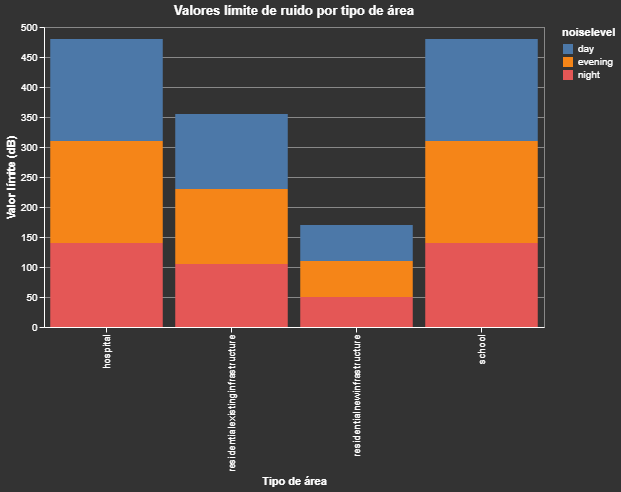

In [22]:
##Visualización 1 — Valores límite por tipo de área

valores_limite_tipo_area = alt.Chart(df_03).mark_bar().encode(
    x=alt.X("areatype:N", title="Tipo de área"),
    y=alt.Y("limitvalue:Q", title="Valor límite (dB)"),
    color="noiselevel:N",
    tooltip=["areatype","noiselevel","limitvalue"]
).properties(
    width=500,
    height=300,
    title="Valores límite de ruido por tipo de área"
)

valores_limite_tipo_area


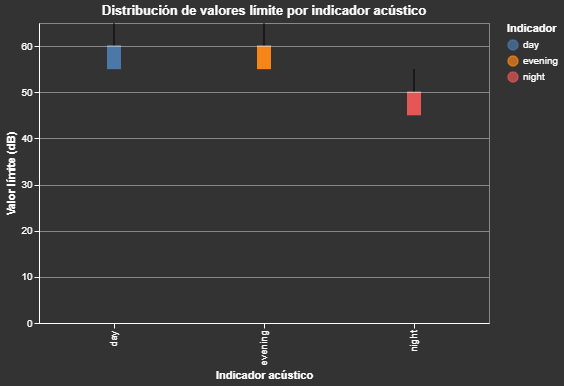

In [26]:
##Visualización 2 — Violines o boxplots por indicador (day/evening/night)
#Lday (día), Levening (tarde) y Lnight (noche) agrupados
#Boxplots para comparar niveles límite entre indicadores: rango, mediana, dispersión, valores máximos y mínimos permitidos en cada periodo

chart2 = alt.Chart(df_03).mark_boxplot().encode(
    x=alt.X("noiselevel:N", title="Indicador acústico"),
    y=alt.Y("limitvalue:Q", title="Valor límite (dB)"),
    color=alt.Color("noiselevel:N", title="Indicador"),
    tooltip=["areatype:N", "noiselevel:N", "limitvalue:Q"]
).properties(
    width=450,
    height=300,
    title="Distribución de valores límite por indicador acústico"
)

chart2

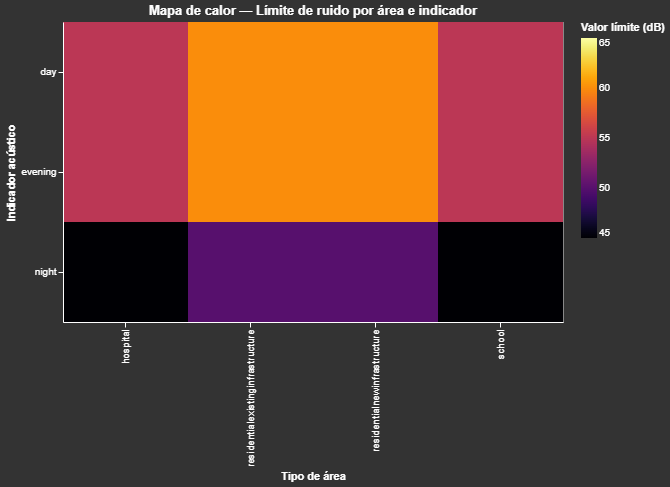

In [27]:
##VISUALIZACIÓN 3 — Heatmap área × indicador acústico
#Este gráfico muestra qué valor límite aplica cada combinación de:
#areaType (hospital, school, industrial…) y noiseLevel (day, evening, night)

chart_heatmap = alt.Chart(df_03).mark_rect().encode(
    x=alt.X("areatype:N", title="Tipo de área"),
    y=alt.Y("noiselevel:N", title="Indicador acústico"),
    color=alt.Color("limitvalue:Q", scale=alt.Scale(scheme="inferno"), title="Valor límite (dB)"),
    tooltip=[
        alt.Tooltip("areatype:N", title="Área"),
        alt.Tooltip("noiselevel:N", title="Indicador"),
        alt.Tooltip("limitvalue:Q", title="Límite dB"),
        alt.Tooltip("status:N", title="Estado legal")
    ]
).properties(
    width=500,
    height=300,
    title="Mapa de calor — Límite de ruido por área e indicador"
)

chart_heatmap




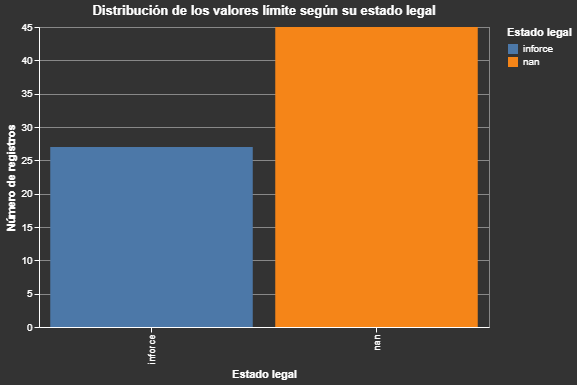

In [29]:
##VISUALIZACIÓN 4 — Barras por estado legal

#Permite revisar cuántos valores límite están: en vigor, planificados, retirados, etc.

chart_status = alt.Chart(df_03).mark_bar().encode(
    x=alt.X("status:N", title="Estado legal"),
    y=alt.Y("count():Q", title="Número de registros"),
    color=alt.Color("status:N", title="Estado legal"),
    tooltip=["status:N", "count():Q"]
).properties(
    width=450,
    height=300,
    title="Distribución de los valores límite según su estado legal"
)

chart_status
